# Atividade 1

Todas as perguntas contidas nos problemas são respondidas por células markdown nos respectivos blocos do problema

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [97]:
def run_armijo(func, x, g, alpha, beta, c):
    while func(x - alpha * g) > func(x) - c * alpha * np.dot(g, g):
        alpha *= beta
    return alpha


def gradient_descent(func, grad, x0, alpha=1, max_iters=1000,
                     backtrack=True, beta=0.5, c=1e-4, tol=1e-6):
    """As duas condições de parada foram implementadas, embora o max_iter ter 
    sido responsável por maior parte das paradas. A função pode rodar com ou sem o 
    backtrack e armijo, aceitando um alpha qualquer."""
    x = x0.copy().astype(float)

    n_func_evals = 0
    n_grad_evals = 0

    def func_counted(x):
        nonlocal n_func_evals
        n_func_evals += 1
        return func(x)

    def grad_counted(x):
        nonlocal n_grad_evals
        n_grad_evals += 1
        return grad(x)

    path        = [x.copy()]
    f_history   = [func_counted(x)]
    g_history   = []

    n_iters = 0

    while n_iters < max_iters:
        g = grad_counted(x)
        g_norm = np.linalg.norm(g)
        g_history.append(g_norm)

        if g_norm <= tol:
            break

        step = alpha
        if backtrack:
            step = run_armijo(func_counted, x, g, step, beta, c)

        x = x - step * g

        if np.any(np.isnan(x)) or np.any(np.isinf(x)):
            break

        path.append(x.copy())
        f_history.append(func_counted(x))
        n_iters += 1

    final_grad_norm = np.linalg.norm(grad_counted(x)) if len(g_history) == 0 else g_history[-1]

    return {
        "path":            np.array(path),          
        "n_iters":         n_iters,                
        "f_final":         f_history[-1],         
        "grad_norm_final": final_grad_norm,         
        "n_func_evals":    n_func_evals,          
        "n_grad_evals":    n_grad_evals,           
        "n_hess_evals":    0,                     
        "f_history":       np.array(f_history),    
        "grad_norm_history": np.array(g_history),   
    }

In [98]:
def newton_method_id(func, grad1, grad2, x0, max_iters=1000, tol=1e-6):
    """
    Todas as funções trabalhadas são bidimensionais, função
    acabou não sendo utilizada
    """
    n_func_evals = 0
    n_grad_evals = 0
    n_hess_evals = 0

    def func_c(x):
        nonlocal n_func_evals; n_func_evals += 1; return func(x)

    def grad1_c(x):
        nonlocal n_grad_evals; n_grad_evals += 1; return grad1(x)

    def grad2_c(x):
        nonlocal n_hess_evals; n_hess_evals += 1; return grad2(x)

    p         = float(x0)
    path      = [np.array([p])]
    f_history = [func_c(p)]
    g_history = []
    n_iters   = 0

    while n_iters < max_iters:
        g      = grad1_c(p)
        g_norm = abs(g)
        g_history.append(g_norm)

        if g_norm <= tol:
            break

        h = grad2_c(p)
        if abs(h) < 1e-15:  # hessiana -> passo indefinido
            break

        p = p - g / h

        if np.isnan(p) or np.isinf(p):
            break

        path.append(np.array([p]))
        f_history.append(func_c(p))
        n_iters += 1

    return {
        "path":              np.array(path),
        "n_iters":           n_iters,
        "f_final":           f_history[-1],
        "grad_norm_final":   g_history[-1] if g_history else abs(grad1_c(p)),
        "n_func_evals":      n_func_evals,
        "n_grad_evals":      n_grad_evals,
        "n_hess_evals":      n_hess_evals,
        "f_history":         np.array(f_history),
        "grad_norm_history": np.array(g_history),
    }


def newton_method_bid(func, gradf, H, x0, max_iters=1000, tol=1e-6):
    """
    Newton para o caso multidimensional. Retorna o step_staus, que diz
    se o algoritimo foi em direção de subida descida ou neutro no passo 
    da iteração.
    """
    n_func_evals = 0
    n_grad_evals = 0
    n_hess_evals = 1

    def func_c(x):
        nonlocal n_func_evals; n_func_evals += 1; return func(x)

    def gradf_c(x):
        nonlocal n_grad_evals; n_grad_evals += 1; return gradf(x)

    Hinv = np.linalg.inv(H)
    p    = np.asarray(x0, dtype=float)

    path        = [p.copy()]
    f_history   = [func_c(p)]
    g_history   = []
    step_status = []
    n_iters     = 0

    for _ in range(max_iters):
        g      = gradf_c(p)
        g_norm = np.linalg.norm(g)
        g_history.append(g_norm)

        if g_norm <= tol:
            break

        d   = -Hinv @ g          
        dot = float(g @ d)      

        p = p + d                

        if np.any(np.isnan(p)) or np.any(np.isinf(p)):
            break

        if dot < 0:
            step_status.append('down')
        elif dot > 0:
            step_status.append('up')
        else:
            step_status.append('neutral')

        path.append(p.copy())
        f_history.append(func_c(p))
        n_iters += 1

    return {
        "path":              np.array(path),
        "n_iters":           n_iters,
        "f_final":           f_history[-1],
        "grad_norm_final":   g_history[-1] if g_history else np.linalg.norm(gradf_c(p)),
        "n_func_evals":      n_func_evals,
        "n_grad_evals":      n_grad_evals,
        "n_hess_evals":      n_hess_evals,
        "f_history":         np.array(f_history),
        "grad_norm_history": np.array(g_history),
        "step_status":       step_status,   
    }


Funções que usei para criar os gráficos

In [99]:
def plot_contour_with_path(path, func, x, y):
    X, Y = np.meshgrid(x, y)
    Z = func([X, Y])

    plt.contourf(X, Y, Z,
                 levels=30,
                 cmap='viridis')
    plt.colorbar(label='log(1 + f(x,y))')
    plt.plot(path[:, 0], path[:, 1], 'r.-', label='path')
    plt.plot(path[0, 0], path[0, 1], 'go', markersize=10, label='start')
    plt.plot(path[-1, 0], path[-1, 1], 'r*', markersize=15, label='end')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_1v_path(path, f, xs):
    plt.plot(xs, f([xs]), label='f(x)')
    plt.plot(path, f([path]), 'r.-', label='path')
    plt.plot(path[0],  f([path[0]]),  'go', markersize=10, label='start')
    plt.plot(path[-1], f([path[-1]]), 'r*', markersize=15, label='end')
    plt.legend(); plt.xlabel('x'); plt.ylabel('f(x)')
    plt.show()

In [100]:
def plot_convergence(result: dict):
    iters_f = np.arange(len(result["f_history"]))
    iters_g = np.arange(len(result["grad_norm_history"]))

    hess_str = (f" H={result['n_hess_evals']}"
                if result.get("n_hess_evals", 0) > 0 else "")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(iters_f, result["f_history"], color="steelblue", linewidth=1.8)
    axes[0].set_xlabel("Iteração k")
    axes[0].set_ylabel("f(xₖ)")
    axes[0].set_title("Valor da função")
    axes[0].grid(True, linestyle="--", alpha=0.5)

    axes[1].semilogy(iters_g, result["grad_norm_history"], color="tomato", linewidth=1.8)
    axes[1].set_xlabel("Iteração k")
    axes[1].set_ylabel("‖∇f(xₖ)‖")
    axes[1].set_title("Norma do gradiente (escala log)")
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

Funções dos problemas

In [101]:
def p1(x): return 1000 * x[0]**2 + x[1]**2
def p2(x): return (x[0] + 2*x[1] - 7)**2 + (2*x[0] + x[1] - 5)**2


def p3(x): return (1.5 - x[0] + x[0]*x[1])**2 + (2.25 - x[0] +
                                                 x[0]*(x[1]**2))**2 + (2.625 - x[0] + x[0]*(x[1]**3))**2


def p4(x): return np.sin(x[0] + x[1]) + \
    (x[0] - x[1])**2 - 1.5*x[0] + 2.5*x[1] + 1

### Problema 1

d) com o passo constante foi possivel chegar rápidamente ao vale, apesar disso o lento movimento do método não permitiu atingir o ponto mínimo com apenas 1000 iterações. A implementação com armijo e backtrack teve por outro lado dificuldade para encontrar o vale, saltanto por entre os lados até o encontrar, porém com o mesmo número de iterações da anterior apresentou um resultado melhor por se aproximar mais do mínimo.

e)

f) Em comparação, o método de newton pode encontar o mínimo rápidamente, logo no primeiro passo que deu, sendo o único algoritimo que pode achar o mínimo

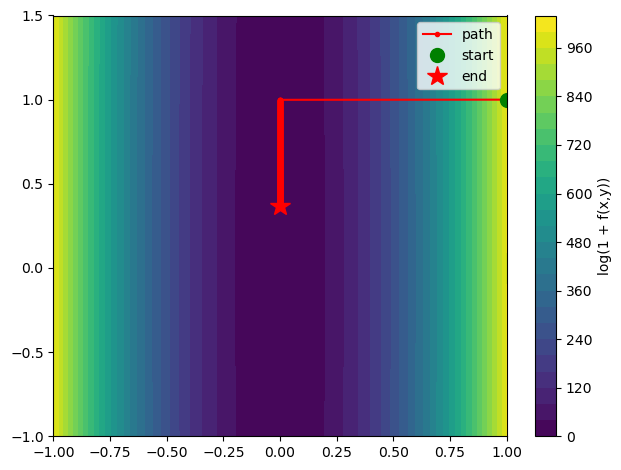

In [102]:
otimization = gradient_descent(p1, lambda x: np.array(
    [2000*x[0], 2*x[1]]), x0=np.array([1, 1]), backtrack=False, alpha=0.0005)

plot_contour_with_path(otimization['path'], p1,
                       x=np.linspace(-1, 1, 100), y=np.linspace(-1, 1.5, 100))

Iterações:          1000
f final:            1.351999e-01
‖∇f‖ final:        7.361270e-01
Avaliações f:       1001
Avaliações ∇f:      1000
Avaliações Hessiana:0


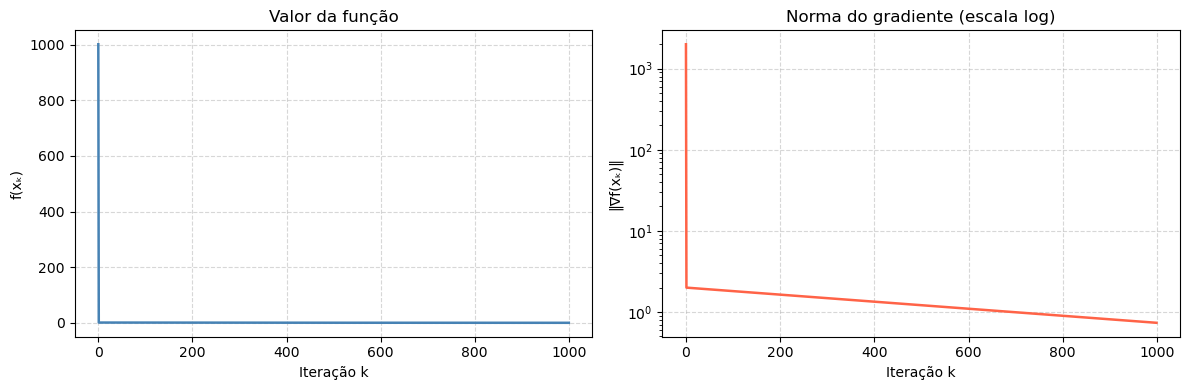

In [103]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana:{otimization['n_hess_evals']}")

plot_convergence(otimization)

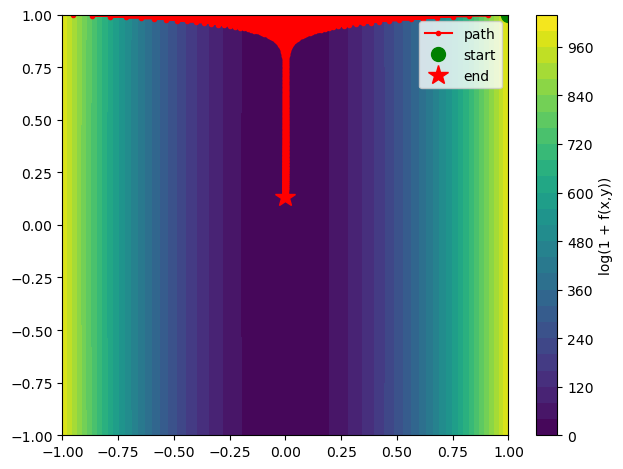

In [104]:
otimization = gradient_descent(
    p1, lambda x: np.array([2000*x[0], 2*x[1]]), x0=np.array([1, 1]))
plot_contour_with_path(otimization['path'], p1,
                       x=np.linspace(-1, 1, 100), y=np.linspace(-1, 1, 100))

Iterações:          1000
f final:            1.754793e-02
‖∇f‖ final:        3.724991e-01
Avaliações f:       22929
Avaliações ∇f:      1000
Avaliações Hessiana:0


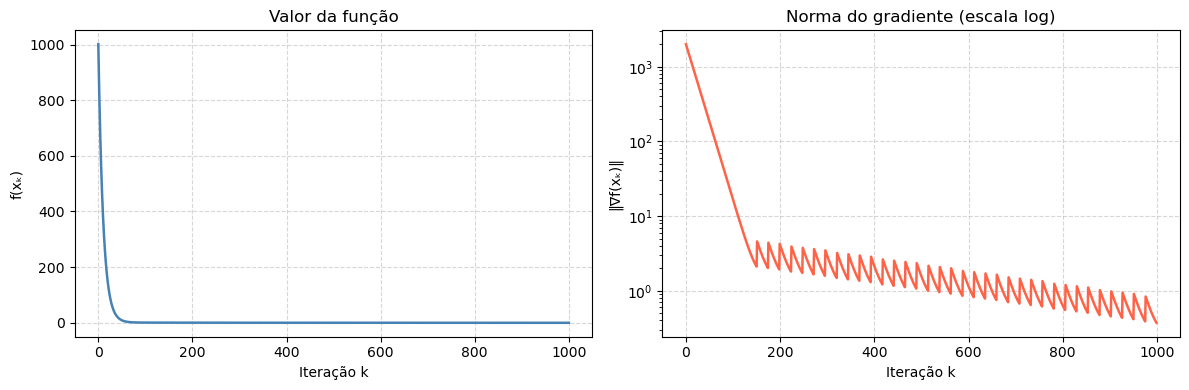

In [105]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana:{otimization['n_hess_evals']}")

plot_convergence(otimization)

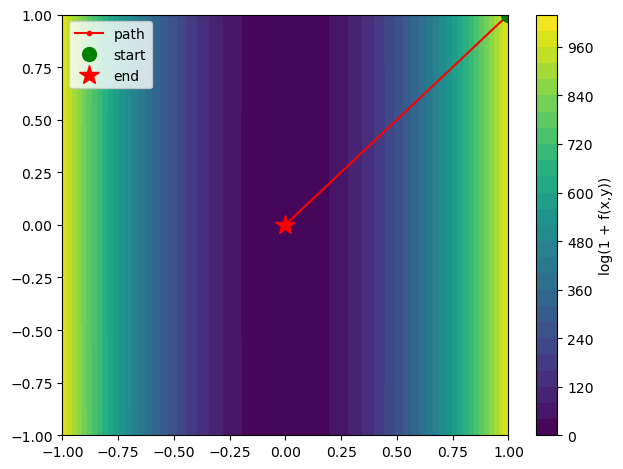

In [106]:
otimization = newton_method_bid(p1, x0=np.array([1, 1]), gradf=lambda x: np.array([
                                   2000*x[0], 2*x[1]]), H=np.array([[2000, 0], [0, 2]]))
plot_contour_with_path(
    otimization['path'], p1, x=np.linspace(-1, 1, 100), y=np.linspace(-1, 1, 100))

Iterações:          1
f final:            0.000000e+00
‖∇f‖ final:        0.000000e+00
Avaliações f:       2
Avaliações ∇f:      2
Avaliações Hessiana:1


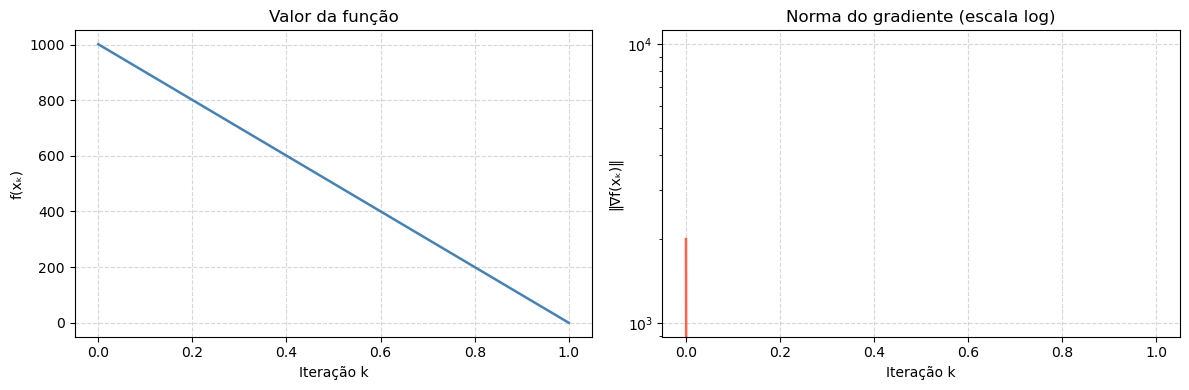

In [107]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana:{otimization['n_hess_evals']}")

plot_convergence(otimization)

### Problema 2

d) O único método que não atingiu o limite de iterações foi o de newton, com apenas 68, e foi ele também que econtrou o menor ponto para a função em comparação com os demais. A versão de passo constante se saiu melhor que a com backtrack e armijo, pois pode atingir um ponto menor. O mesmo problema tornou a acontecer com a versão backtrack armijo, os primeiros passos ocilam de um lado para outro, até formar um funil que caminha lentamente para o mínimo.

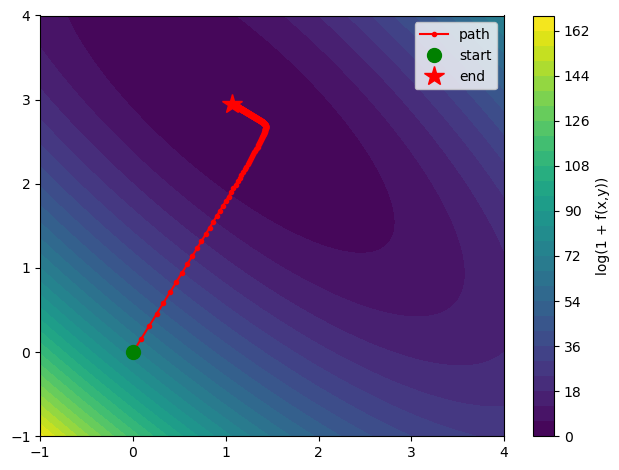

In [108]:
otimization = gradient_descent(p2, lambda x: np.array([10*(x[0] + 2*x[1] - 7) + 4*(2*x[0] + x[1] - 5), 20*(
    x[0] + 2*x[1] - 7) + 4*(2*x[0] + x[1] - 5)]), x0=np.array([0, 0]), backtrack=False, alpha=1e-3)
plot_contour_with_path(otimization['path'], p2,
                       x=np.linspace(-1, 4, 100), y=np.linspace(-1, 4, 100))

Iterações:          1000
f final:            9.218824e-03
‖∇f‖ final:        1.682614e-01
Avaliações f:       1001
Avaliações ∇f:      1000
Avaliações Hessiana:0


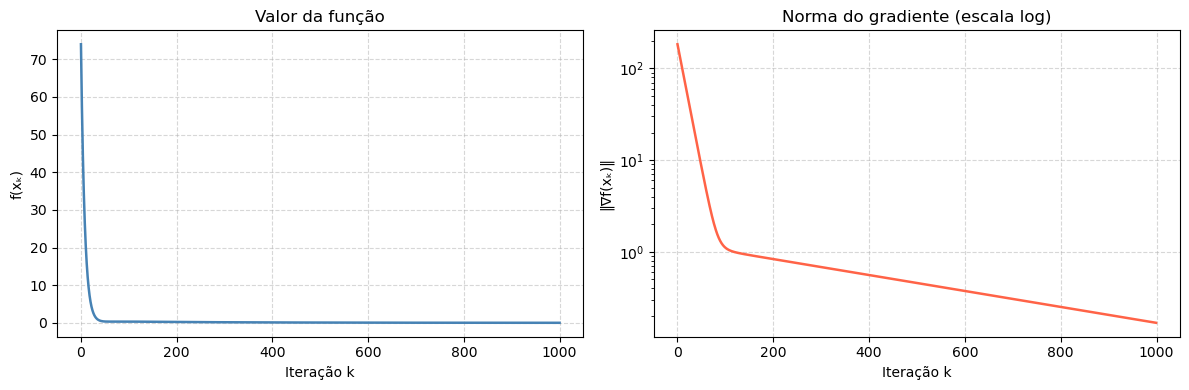

In [109]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana:{otimization['n_hess_evals']}")

plot_convergence(otimization)

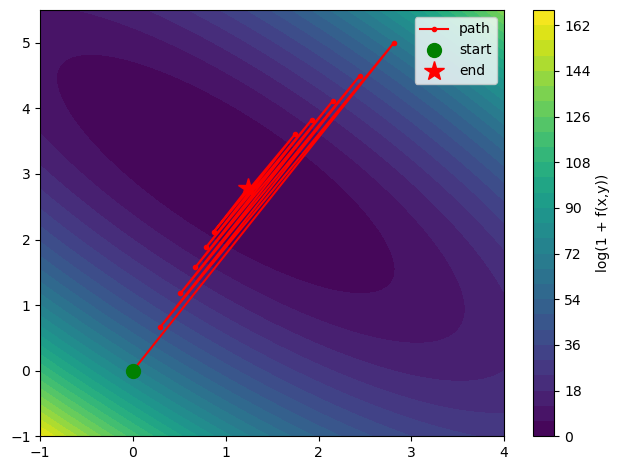

In [110]:
otimization = gradient_descent(p2, lambda x: np.array([10*(x[0] + 2*x[1] - 7) + 4*(
    2*x[0] + x[1] - 5), 20*(x[0] + 2*x[1] - 7) + 4*(2*x[0] + x[1] - 5)]), x0=np.array([0, 0]))
plot_contour_with_path(otimization['path'], p2,
                       x=np.linspace(-1, 4, 100), y=np.linspace(-1, 5.5, 100))

Iterações:          1000
f final:            1.057188e-01
‖∇f‖ final:        2.756502e+00
Avaliações f:       109553
Avaliações ∇f:      1000
Avaliações Hessiana:0


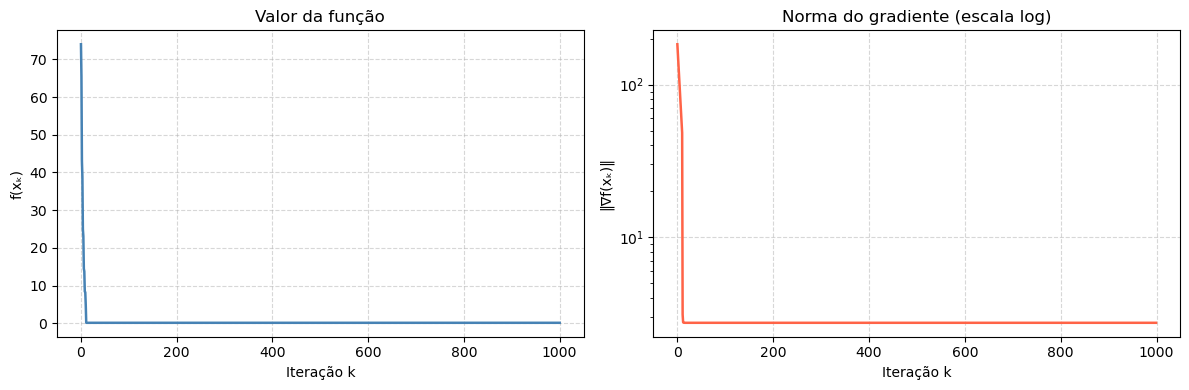

In [111]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana:{otimization['n_hess_evals']}")

plot_convergence(otimization)

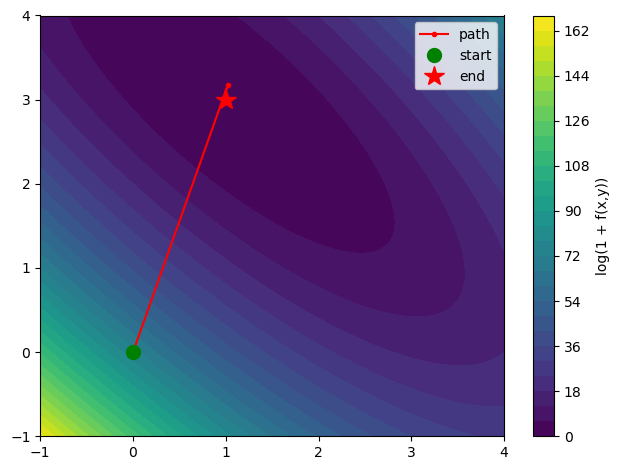

In [112]:
otimization = newton_method_bid(p2, x0=np.array([0, 0]), gradf=lambda x: np.array(
    [10*(x[0] + 2*x[1] - 7) + 4*(2*x[0] + x[1] - 5), 20*(x[0] + 2*x[1] - 7) + 4*(2*x[0] + x[1] - 5)]), H=np.array([[10 + 16, 20], [20, 40 + 4]]))
plot_contour_with_path(
    otimization['path'], p2, x=np.linspace(-1, 4, 100), y=np.linspace(-1, 4, 100))

Iterações:          68
f final:            2.892181e-13
‖∇f‖ final:        9.475097e-07
Avaliações f:       69
Avaliações ∇f:      69
Avaliações Hessiana:1


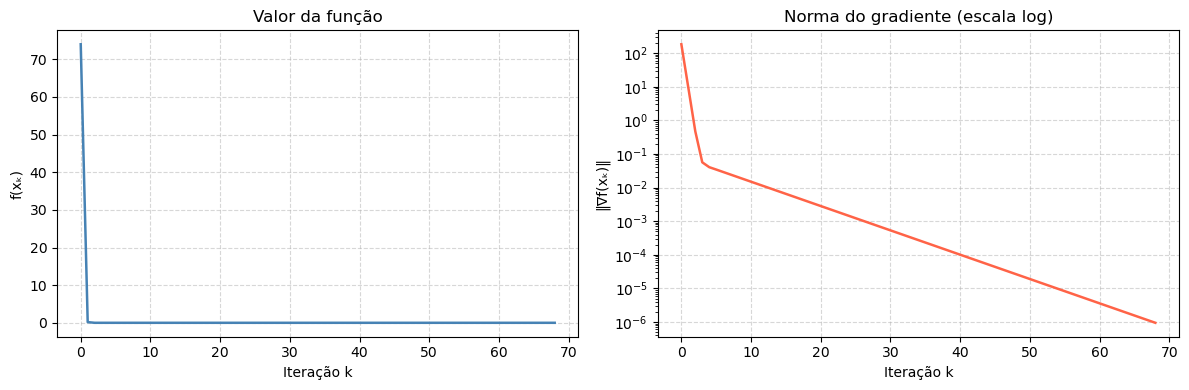

In [113]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana:{otimization['n_hess_evals']}")

plot_convergence(otimization)

### Problema 3

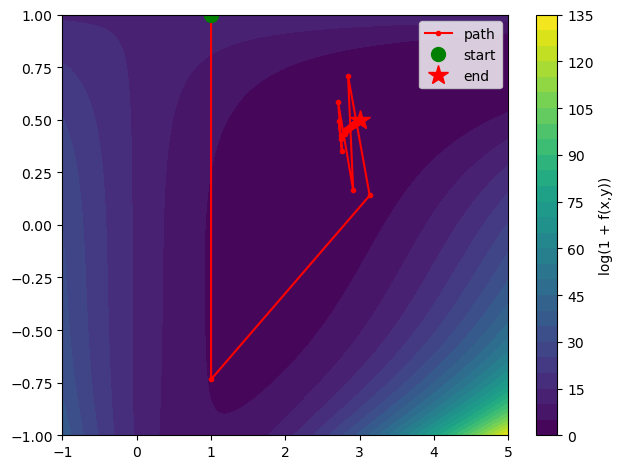

In [114]:
otimization = gradient_descent(
    p3,
    lambda x: np.array([
        2*(1.5 - x[0] + x[0]*x[1])*(-1 + x[1])
        + 2*(2.25 - x[0] + x[0]*(x[1]**2))*(-1 + x[1]**2)
        + 2*(2.625 - x[0] + x[0]*(x[1]**3))*(-1 + x[1]**3),

        2*(1.5 - x[0] + x[0]*x[1])*(x[0])
        + 2*(2.25 - x[0] + x[0]*(x[1]**2))*(2*x[0]*x[1])
        + 2*(2.625 - x[0] + x[0]*(x[1]**3))*(3*x[0]*(x[1]**2))
    ]),
    x0=np.array([1, 1]),
)

plot_contour_with_path(
    otimization['path'],
    p3,
    x=np.linspace(-1, 5, 100),
    y=np.linspace(-1, 1, 100)
)

Iterações:          786
f final:            8.457618e-13
‖∇f‖ final:        9.111608e-07
Avaliações f:       9439
Avaliações ∇f:      787
Avaliações Hessiana:0


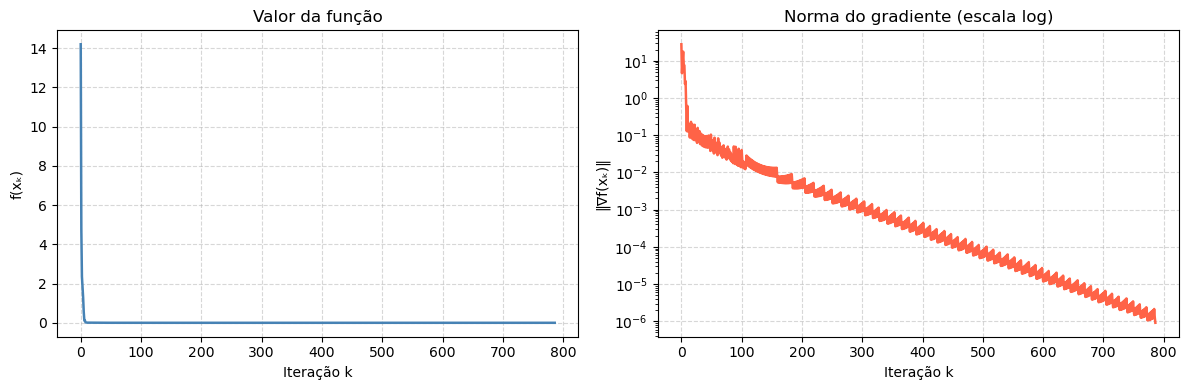

In [115]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana:{otimization['n_hess_evals']}")

plot_convergence(otimization)

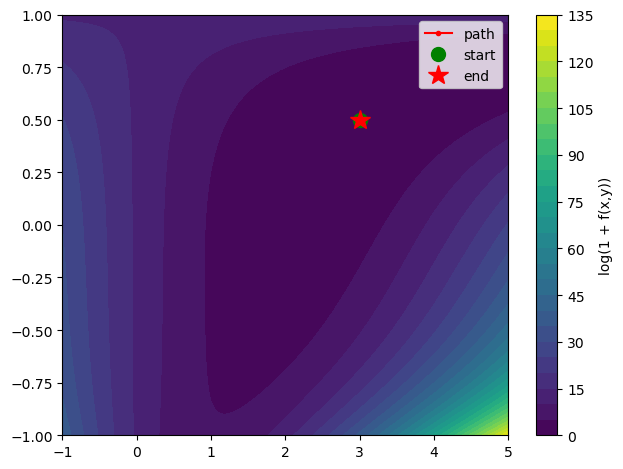

In [116]:
otimization = gradient_descent(
    p3,
    lambda x: np.array([
        2*(1.5 - x[0] + x[0]*x[1])*(-1 + x[1])
        + 2*(2.25 - x[0] + x[0]*(x[1]**2))*(-1 + x[1]**2)
        + 2*(2.625 - x[0] + x[0]*(x[1]**3))*(-1 + x[1]**3),

        2*(1.5 - x[0] + x[0]*x[1])*(x[0])
        + 2*(2.25 - x[0] + x[0]*(x[1]**2))*(2*x[0]*x[1])
        + 2*(2.625 - x[0] + x[0]*(x[1]**3))*(3*x[0]*(x[1]**2))
    ]),
    x0=np.array([3, 0.5]),
)

plot_contour_with_path(
    otimization['path'],
    p3,
    x=np.linspace(-1, 5, 100),
    y=np.linspace(-1, 1, 100)
)

Iterações:          0
f final:            0.000000e+00
‖∇f‖ final:        0.000000e+00
Avaliações f:       1
Avaliações ∇f:      1
Avaliações Hessiana:0


C:\Users\kevin\AppData\Local\Temp\ipykernel_15276\1361107031.py:22: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


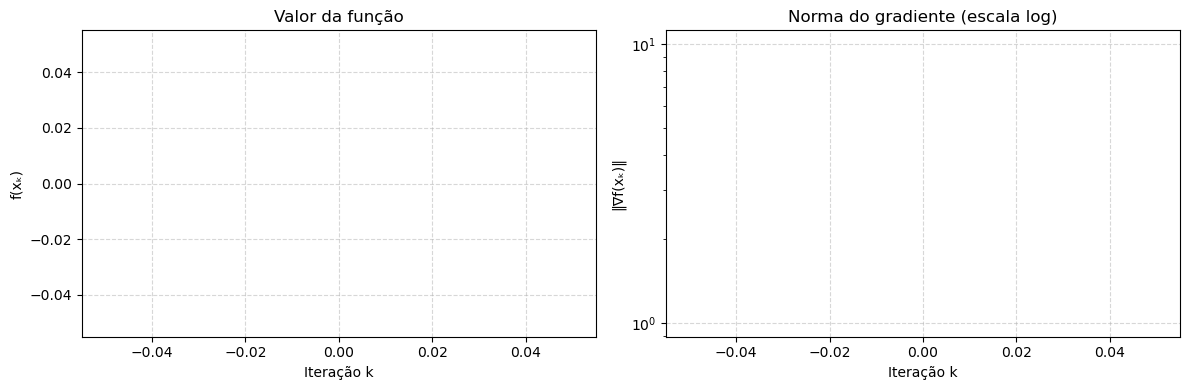

In [117]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana:{otimization['n_hess_evals']}")

plot_convergence(otimization)

C:\Users\kevin\AppData\Local\Temp\ipykernel_15276\849149248.py:6: RuntimeWarning: overflow encountered in scalar power
  x[0]*(x[1]**2))**2 + (2.625 - x[0] + x[0]*(x[1]**3))**2
c:\Users\kevin\anaconda3\Lib\site-packages\numpy\linalg\_linalg.py:2792: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\kevin\AppData\Local\Temp\ipykernel_15276\3794685047.py:93: RuntimeWarning: overflow encountered in matmul
  dot = float(g @ d)
C:\Users\kevin\AppData\Local\Temp\ipykernel_15276\849149248.py:5: RuntimeWarning: overflow encountered in scalar multiply
  def p3(x): return (1.5 - x[0] + x[0]*x[1])**2 + (2.25 - x[0] +
C:\Users\kevin\AppData\Local\Temp\ipykernel_15276\3089981682.py:7: RuntimeWarning: overflow encountered in scalar power
  + 2*(2.625 - x[0] + x[0]*(x[1]**3))*(-1 + x[1]**3),
C:\Users\kevin\AppData\Local\Temp\ipykernel_15276\3089981682.py:9: RuntimeWarning: overflow encountered in scalar multiply
  2*(1.5 - x[0] + x[0]*x[1])*(x[0])
C:\Users\kevin\AppData\Local\T

KeyError: (slice(None, None, None), 0)

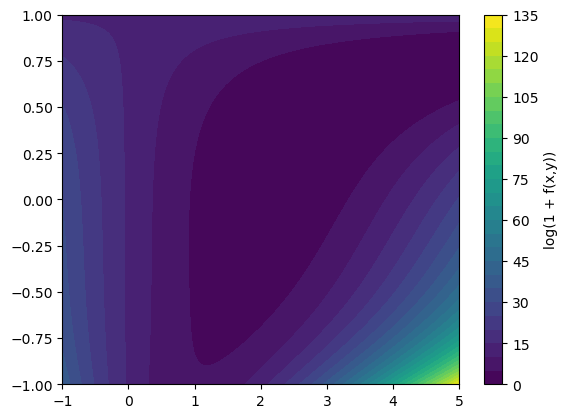

In [118]:
p3_path_newton = newton_method_bid(
    func=p3,
    x0=np.array([1, 1]),
    gradf=lambda x: np.array([
        2*(1.5 - x[0] + x[0]*x[1])*(-1 + x[1])
        + 2*(2.25 - x[0] + x[0]*(x[1]**2))*(-1 + x[1]**2)
        + 2*(2.625 - x[0] + x[0]*(x[1]**3))*(-1 + x[1]**3),

        2*(1.5 - x[0] + x[0]*x[1])*(x[0])
        + 2*(2.25 - x[0] + x[0]*(x[1]**2))*(2*x[0]*x[1])
        + 2*(2.625 - x[0] + x[0]*(x[1]**3))*(3*x[0]*(x[1]**2))
    ]),
    H=np.array([
        [4, 4],
        [4, 8]
    ])
)

plot_contour_with_path(
    p3_path_newton,
    p3,
    x=np.linspace(-1, 5, 100),
    y=np.linspace(-1, 1, 100)
)

### Problema 4

d) Todas as vezes o algoritimo de Newton foi para a direção de descida da função, isso foi provado experimentalmente e pode ser visto nos outputs textuais abaixo dos gráficos de contorno de Newton.

e) Armijo backtrack demonstrou melhor performace que newton, que em todos os caso, ficou pulando do lado para o outro de um vale até estourar as iterações. Os algorítimos testados em 0,0 convergiram para um mínimo local, porém os testes para pontos iniciais mais proximos de -3, -3 foram capazes de econtrar pontos ainda menores que a função atingia.

0,0 Armijo backtrack

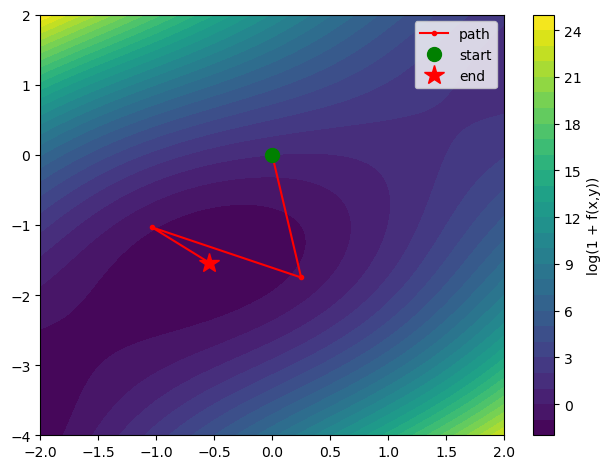

In [ ]:
otimization = gradient_descent(
    p4, lambda x: np.array([
        np.cos(x[0] + x[1]) + 2*(x[0] - x[1]) - 1.5,
        np.cos(x[0] + x[1]) - 2*(x[0] - x[1]) + 2.5
    ]), x0=np.array([0, 0]))
plot_contour_with_path(
    otimization['path'], p4, x=np.linspace(-2, 2, 100), y=np.linspace(-4, 2, 100)
)

Iterações:          30
f final:            -1.913223e+00
‖∇f‖ final:        1.716338e-08
Avaliações f:       109
Avaliações ∇f:      31
Avaliações Hessiana:0


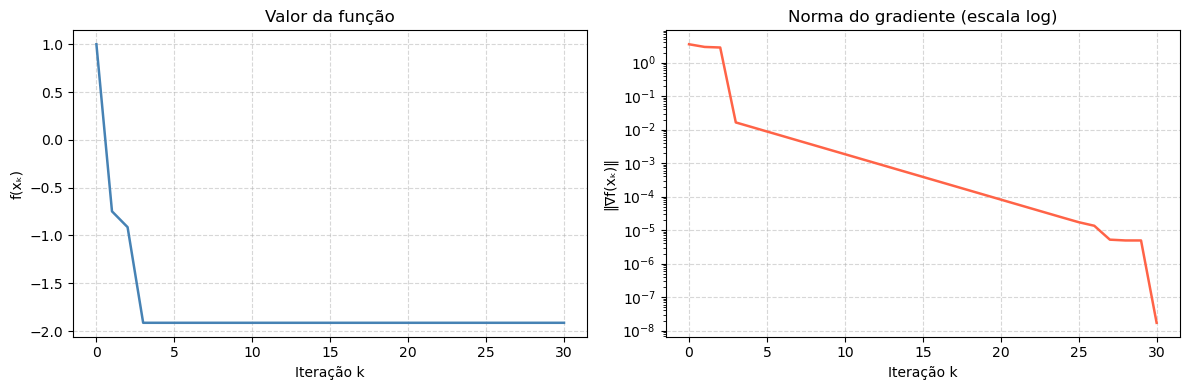

In [ ]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana:{otimization['n_hess_evals']}")

plot_convergence(otimization)

2, -2 Armijo backtrack

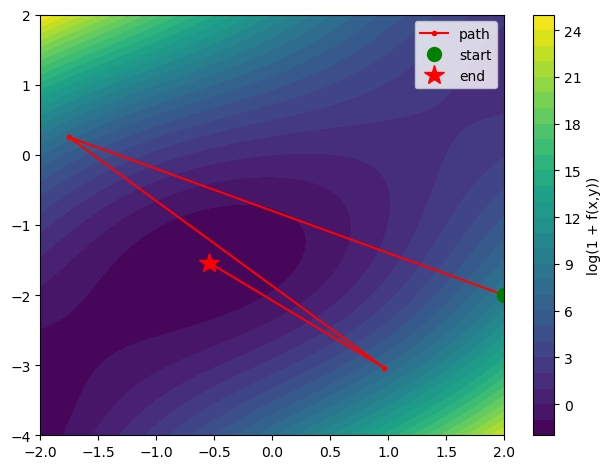

In [ ]:
otimization = gradient_descent(
    p4, lambda x: np.array([
        np.cos(x[0] + x[1]) + 2*(x[0] - x[1]) - 1.5,
        np.cos(x[0] + x[1]) - 2*(x[0] - x[1]) + 2.5
    ]), x0=np.array([2, -2]))
plot_contour_with_path(
    otimization['path'], p4, x=np.linspace(-2, 2, 100), y=np.linspace(-4, 2, 100)
)

Iterações:          28
f final:            -1.913223e+00
‖∇f‖ final:        3.202803e-08
Avaliações f:       103
Avaliações ∇f:      29
Avaliações Hessiana:0


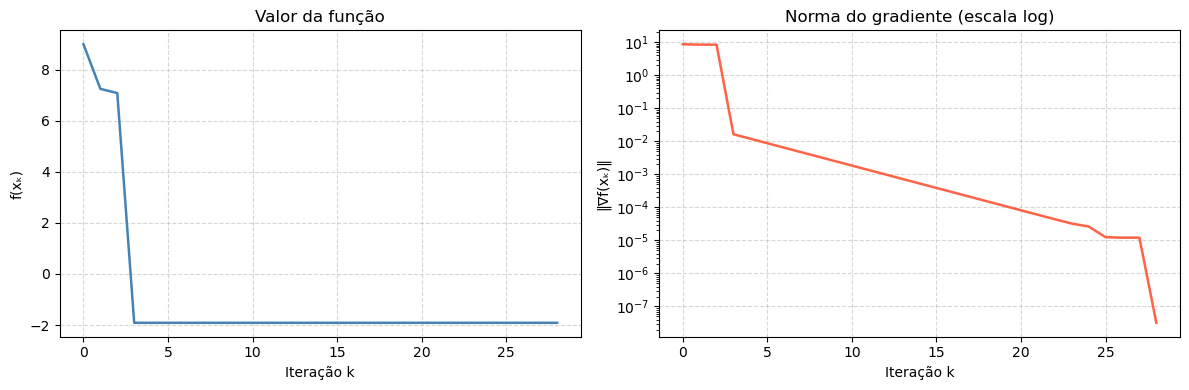

In [ ]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana:{otimization['n_hess_evals']}")

plot_convergence(otimization)

-3, -3 Armijo backtrack

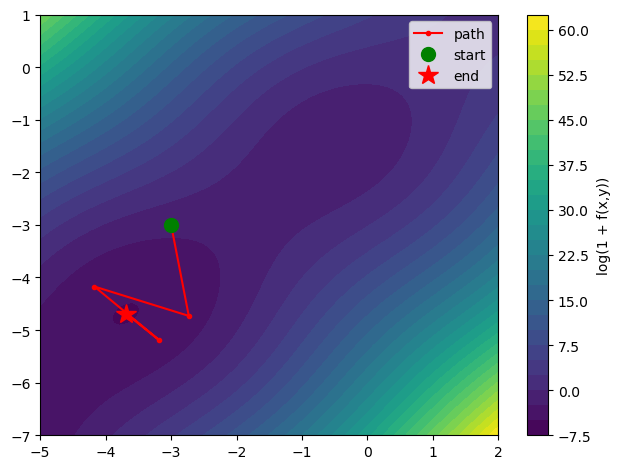

In [ ]:
otimization = gradient_descent(
    p4, lambda x: np.array([
        np.cos(x[0] + x[1]) + 2*(x[0] - x[1]) - 1.5,
        np.cos(x[0] + x[1]) - 2*(x[0] - x[1]) + 2.5
    ]), x0=np.array([-3, -3]))
plot_contour_with_path(
    otimization['path'], p4, x=np.linspace(-5, 2, 100), y=np.linspace(-7, 1, 100)
)

Iterações:          29
f final:            -5.054816e+00
‖∇f‖ final:        3.134365e-08
Avaliações f:       106
Avaliações ∇f:      30
Avaliações Hessiana:0


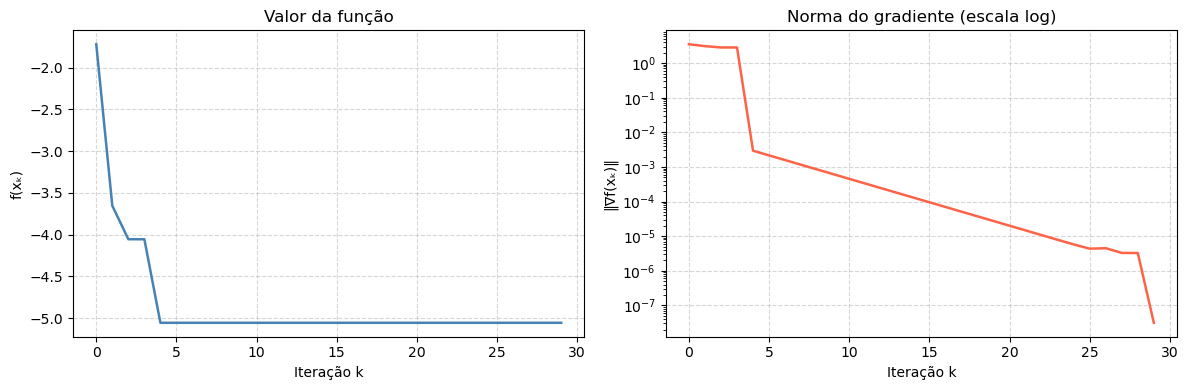

In [ ]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana:{otimization['n_hess_evals']}")

plot_convergence(otimization)

0, 0 Newton

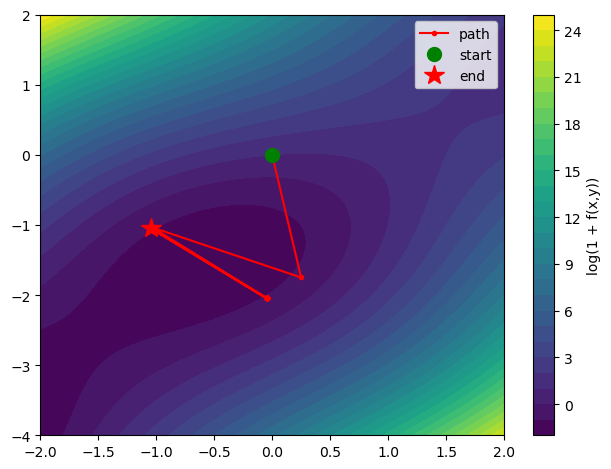

In [123]:
otimization = newton_method_bid(
    p4, 
    x0=np.array([0, 0]), gradf=lambda x: np.array([
        np.cos(x[0] + x[1]) + 2*(x[0] - x[1]) - 1.5,
        np.cos(x[0] + x[1]) - 2*(x[0] - x[1]) + 2.5
    ]), H=np.array([
        [-np.sin(0) + 2, -np.sin(0)],
        [-np.sin(0), -np.sin(0) + 2]
    ])
)   
plot_contour_with_path(
    otimization['path'], p4, x=np.linspace(-2, 2, 100), y=np.linspace(-4, 2, 100)
)

Iterações:          1000
f final:            -9.132230e-01
‖∇f‖ final:        2.828427e+00
Avaliações f:       1001
Avaliações ∇f:      1000
Avaliações Hessiana: 1
Status dos passos: Counter({'down': 1000})


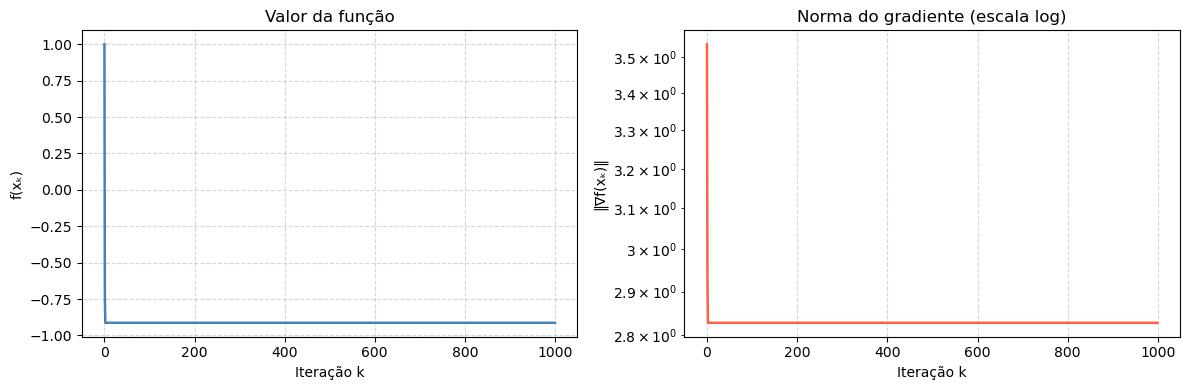

In [124]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana: {otimization['n_hess_evals']}")
print(f"Status dos passos: {Counter(otimization["step_status"])}")


plot_convergence(otimization)

2, -2 Newton

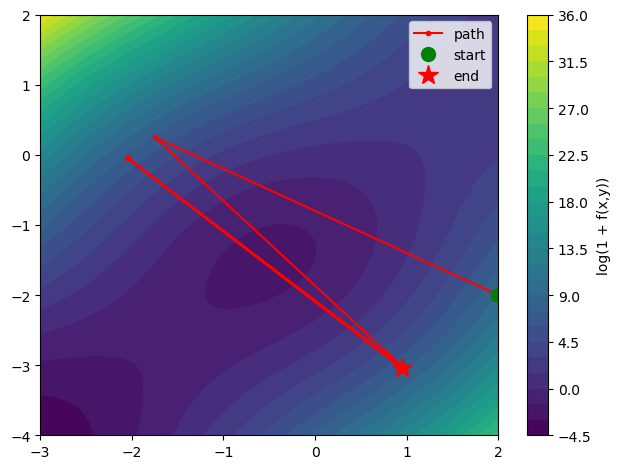

In [125]:
otimization = newton_method_bid(
    p4, 
    x0=np.array([2, -2]), gradf=lambda x: np.array([
        np.cos(x[0] + x[1]) + 2*(x[0] - x[1]) - 1.5,
        np.cos(x[0] + x[1]) - 2*(x[0] - x[1]) + 2.5
    ]), H=np.array([
        [-np.sin(0) + 2, -np.sin(0)],
        [-np.sin(0), -np.sin(0) + 2]
    ])
)   
plot_contour_with_path(
    otimization['path'], p4, x=np.linspace(-3, 2, 100), y=np.linspace(-4, 2, 100)
)

Iterações:          1000
f final:            7.086777e+00
‖∇f‖ final:        8.485281e+00
Avaliações f:       1001
Avaliações ∇f:      1000
Avaliações Hessiana: 1
Status dos passos: Counter({'down': 1000})


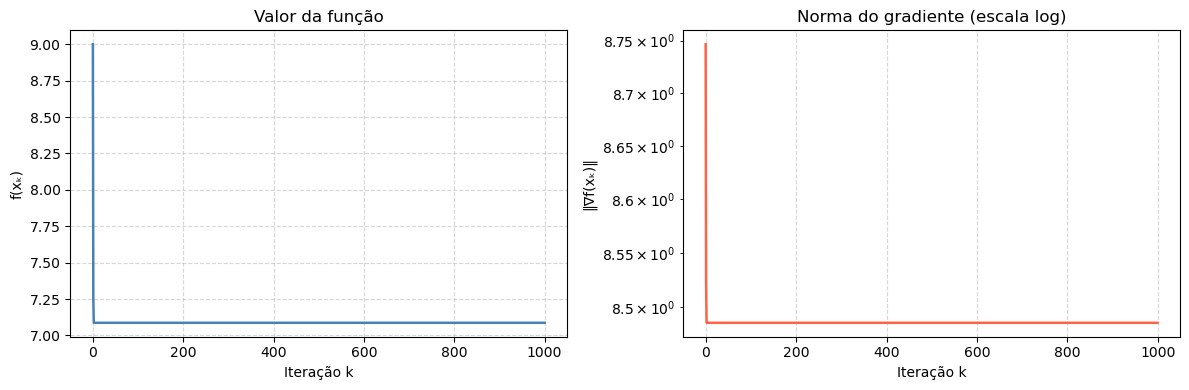

In [126]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana: {otimization['n_hess_evals']}")
print(f"Status dos passos: {Counter(otimization["step_status"])}")


plot_convergence(otimization)

-3, -3 Newton

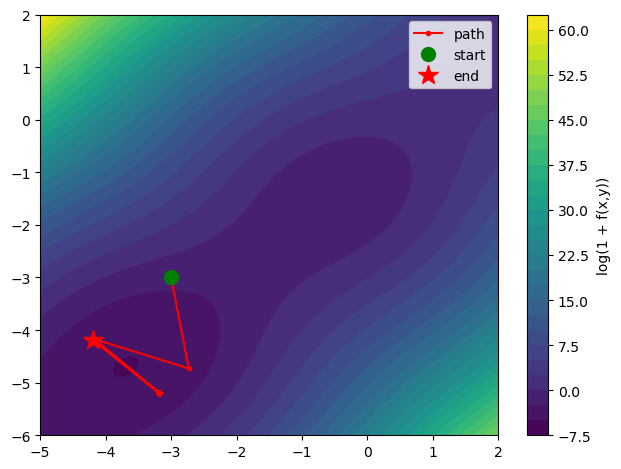

In [127]:
otimization = newton_method_bid(
    p4, 
    x0=np.array([-3, -3]), gradf=lambda x: np.array([
        np.cos(x[0] + x[1]) + 2*(x[0] - x[1]) - 1.5,
        np.cos(x[0] + x[1]) - 2*(x[0] - x[1]) + 2.5
    ]), H=np.array([
        [-np.sin(0) + 2, -np.sin(0)],
        [-np.sin(0), -np.sin(0) + 2]
    ])
)   
plot_contour_with_path(
    otimization['path'], p4, x=np.linspace(-5, 2, 100), y=np.linspace(-6, 2, 100)
)

Iterações:          1000
f final:            -4.054816e+00
‖∇f‖ final:        2.828427e+00
Avaliações f:       1001
Avaliações ∇f:      1000
Avaliações Hessiana: 1
Status dos passos: Counter({'down': 1000})


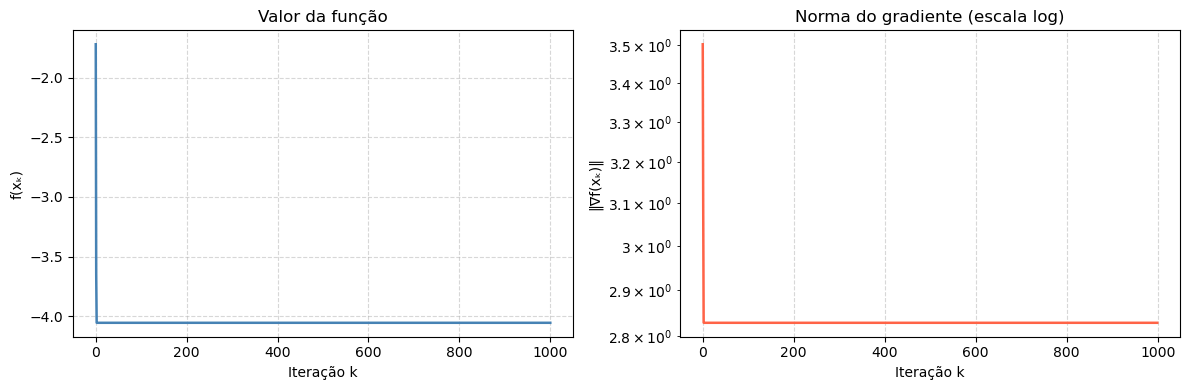

In [128]:
print(f"Iterações:          {otimization['n_iters']}")
print(f"f final:            {otimization['f_final']:.6e}")
print(f"‖∇f‖ final:        {otimization['grad_norm_final']:.6e}")
print(f"Avaliações f:       {otimization['n_func_evals']}")
print(f"Avaliações ∇f:      {otimization['n_grad_evals']}")
print(f"Avaliações Hessiana: {otimization['n_hess_evals']}")
print(f"Status dos passos: {Counter(otimization["step_status"])}")


plot_convergence(otimization)